In [3]:
import csv
import pandas as pd
import numpy as np

In [4]:
raw_df = pd.read_csv(
    "experiment_data.csv", 
    delimiter='\t', 
    names=['client_labda','server_mu', 'alpha', 'active_servers_num', 'run_iterations', 'request_id', 'server_processing_time_ideal', 
           'time_untill_next_client', 'sent_is_cpu','client_measured_time','server_processing_time_measured', 'is_cpu_received'], 
    header=None
)
raw_df.head()

,client_labda,server_mu,alpha,active_servers_num,run_iterations,request_id,server_processing_time_ideal,time_untill_next_client,sent_is_cpu,client_measured_time,server_processing_time_measured,is_cpu_received
0,0.3,1,0.1,1,500,0,0.617761,0.246800,0,623.0,0.618305,0.0
1,0.3,1,0.1,1,500,1,0.570009,0.125432,0,1054.0,0.570570,0.0
2,0.3,1,0.1,1,500,2,0.248522,0.005538,0,1288.0,0.248974,0.0
3,0.3,1,0.1,1,500,3,0.578565,0.505948,0,1358.0,0.579098,0.0
4,0.3,1,0.1,1,500,4,0.112288,0.157745,0,1298.0,0.112846,0.0


In [5]:
print(f"NO RESULT WAS SENT FOR - {sum(raw_df['sent_is_cpu']!=raw_df['is_cpu_received'])} requests")

NO RESULT WAS SENT FOR - 187 requests


## Data cleaning

In [6]:
received_results_df = raw_df[raw_df['sent_is_cpu']==raw_df['is_cpu_received']].copy()

In [7]:
received_results_df = received_results_df[received_results_df['run_iterations'] == 500]

In [8]:
received_results_df.info()

<class 'pandas.DataFrame'>
Index: 5077826 entries, 0 to 5078012
Data columns (total 12 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   client_labda                     float64
 1   server_mu                        int64  
 2   alpha                            float64
 3   active_servers_num               int64  
 4   run_iterations                   int64  
 5   request_id                       int64  
 6   server_processing_time_ideal     float64
 7   time_untill_next_client          float64
 8   sent_is_cpu                      int64  
 9   client_measured_time             float64
 10  server_processing_time_measured  float64
 11  is_cpu_received                  float64
dtypes: float64(7), int64(5)
memory usage: 503.6 MB


## Convert to appropreate datatypes for mem-footprint reduction

In [9]:
received_results_df['client_labda'] = received_results_df['client_labda'].astype('category')

In [10]:
received_results_df['server_mu'] = received_results_df['server_mu'].astype('category')

In [11]:
received_results_df['alpha'] = received_results_df['alpha'].astype('category')

In [12]:
received_results_df['is_cpu_received'] = received_results_df['is_cpu_received'].astype('int64')

In [13]:
received_results_df['sent_is_cpu'] = received_results_df['sent_is_cpu'].astype('bool')

In [14]:
# Convert miliseconds to seconds
MILISECONDS_IN_SECOND = 1000
received_results_df['client_measured_time'] = received_results_df['client_measured_time'] / MILISECONDS_IN_SECOND

In [15]:
# The is_cpu flag must be the same sent_flat==recived_flag
assert(sum(received_results_df['sent_is_cpu'] != received_results_df['is_cpu_received']) == 0)

In [16]:
received_results_df = received_results_df.drop(['is_cpu_received'], axis=1)

In [17]:
received_results_df.info()

<class 'pandas.DataFrame'>
Index: 5077826 entries, 0 to 5078012
Data columns (total 11 columns):
 #   Column                           Dtype   
---  ------                           -----   
 0   client_labda                     category
 1   server_mu                        category
 2   alpha                            category
 3   active_servers_num               int64   
 4   run_iterations                   int64   
 5   request_id                       int64   
 6   server_processing_time_ideal     float64 
 7   time_untill_next_client          float64 
 8   sent_is_cpu                      bool    
 9   client_measured_time             float64 
 10  server_processing_time_measured  float64 
dtypes: bool(1), category(3), float64(4), int64(3)
memory usage: 329.3 MB


## Drawing section

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial
from scipy.optimize import root_scalar
from scipy.interpolate import RBFInterpolator

## Investigation of truthness

In [19]:
investigate_df = received_results_df.groupby(['alpha', 'active_servers_num'], observed=False)[
    ["server_processing_time_ideal", "server_processing_time_measured", "client_measured_time"]
].mean()

investigate_df = investigate_df.dropna(axis=0, how='all')
investigate_df = investigate_df.reset_index()
investigate_df['alpha'] = investigate_df['alpha'].astype('float64')
investigate_df = investigate_df[investigate_df['alpha'].isin({0.0, 0.2, 0.4, 0.6, 0.8, 1.0})]
investigate_df = investigate_df[(investigate_df['active_servers_num'] > 20) & (investigate_df['active_servers_num'] < 694)]
investigate_df

,alpha,active_servers_num,server_processing_time_ideal,server_processing_time_measured,client_measured_time
20,0.0,21,0.954284,0.954998,1.116252
21,0.0,22,1.001952,1.002723,1.199862
22,0.0,23,1.000461,1.001177,1.151056
23,0.0,24,1.022919,1.023575,1.176098
24,0.0,25,0.985568,0.986301,1.127192
...,...,...,...,...,...
5378,1.0,689,0.976179,1.215785,1.240089
5379,1.0,690,1.032479,1.259932,1.297202
5380,1.0,691,1.025053,1.229601,1.249569
5381,1.0,692,1.045300,1.280784,1.321376


In [22]:
# Load your dataframe (assuming df is already loaded)
lam = 1.0  # as stated in your paper

def calc_T_theor(mu, n, lam):
    """
    Calculates the theoretical total time T for an M/M/n queue.
    mu: service rate of one container
    n: number of containers
    lam: arrival rate
    """
    rho = lam / (n * mu)
    if rho >= 1:
        return np.inf  # unstable system
    
    # Calculate p0
    sum_k = 0.0
    for k in range(n):
        sum_k += (lam/mu)**k / factorial(k)
    
    p0 = 1.0 / (sum_k + (lam/mu)**n / factorial(n) * (1 / (1 - rho)))
    
    # Average queue length
    Lq = ( (lam/mu)**n * rho ) / ( factorial(n) * (1 - rho)**2 ) * p0
    
    # Average requests in service (Erlang's C formula)
    LN = rho
    
    L = LN + Lq
    return L / lam

In [23]:
investigate_df

,alpha,active_servers_num,server_processing_time_ideal,server_processing_time_measured,client_measured_time
20,0.0,21,0.954284,0.954998,1.116252
21,0.0,22,1.001952,1.002723,1.199862
22,0.0,23,1.000461,1.001177,1.151056
23,0.0,24,1.022919,1.023575,1.176098
24,0.0,25,0.985568,0.986301,1.127192
...,...,...,...,...,...
5378,1.0,689,0.976179,1.215785,1.240089
5379,1.0,690,1.032479,1.259932,1.297202
5380,1.0,691,1.025053,1.229601,1.249569
5381,1.0,692,1.045300,1.280784,1.321376


In [24]:
experiment_df = investigate_df

In [25]:
import numpy as np
import pandas as pd
from scipy.optimize import root_scalar

LAMBDA = 0.3

def erlang_c(n, rho):
    """Erlang-C probability that an arriving customer queues."""
    # rho = lambda / (n * mu)
    if rho >= 1.0:
        return 1.0
    # compute sum_{i=0}^{n-1} (n*rho)^i / i!
    terms = np.empty(n)
    terms[0] = 1.0
    for i in range(1, n):
        terms[i] = terms[i-1] * (n * rho) / i
    sum_terms = np.sum(terms)
    last_term = terms[-1] * (n * rho) / n   # (n*rho)^n / n!
    C = last_term / (sum_terms * (1 - rho) + last_term)
    return C

def mean_response_time(mu, n):
    """M/M/n mean system time."""
    if mu <= LAMBDA / n:
        return np.inf
    rho = LAMBDA / (n * mu)
    C = erlang_c(n, rho)
    T = 1.0 / mu + C / (n * mu - LAMBDA)
    return T

def solve_mu(target_T, n):
    """Return mu such that mean_response_time(mu, n) == target_T."""
    # Lower bound: just above stability limit
    low = LAMBDA / n + 1e-12
    # Find an upper bound by doubling until T(mu) < target_T
    high = 1.0
    while mean_response_time(high, n) > target_T:
        high *= 2.0
        if high > 1e6:  # safety valve
            raise ValueError("No valid mu found in reasonable range")
    # Bisection
    for _ in range(100):
        mid = (low + high) / 2.0
        T_mid = mean_response_time(mid, n)
        if T_mid > target_T:
            low = mid
        else:
            high = mid
        if high - low < 1e-12:
            break
    return (low + high) / 2.0

# Group by n and alpha, compute mean measured time
grouped = experiment_df.groupby(['active_servers_num', 'alpha'])['client_measured_time'].mean()

mu_dict = {}
for (n, alpha), T_mean in grouped.items():
    # Ensure n is int
    n = int(n)
    try:
        mu = solve_mu(T_mean, n)
        mu_dict[(n, alpha)] = mu
    except ValueError as e:
        print(f"Failed for n={n}, alpha={alpha}: {e}")

# mu_dict now contains the inferred service rates

In [26]:
from scipy.signal import savgol_filter
# Apply Savitzky-Golay filter
window_length = 11  # Must be odd
polyorder = 3

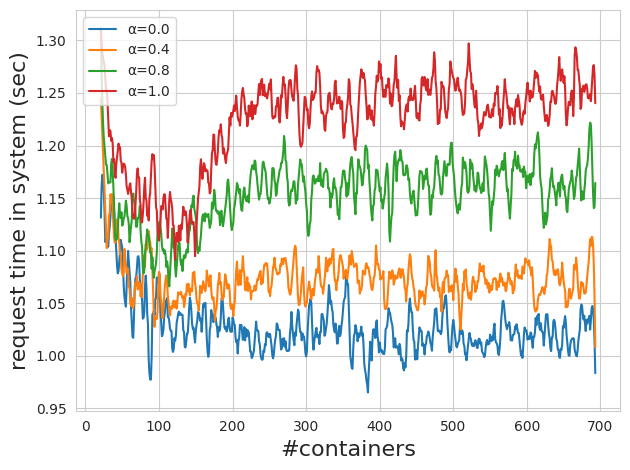

In [28]:
# Create the figure and a flattened array of axes objects
# fig, axes = plt.subplots(figsize=(12, 8))
fig, axes = plt.subplots()

for i, (alpha, alpha_df) in enumerate(investigate_df.groupby('alpha')):

    if alpha in {0.0, 0.4, 0.8, 1.0}:
        x = alpha_df['active_servers_num']
    #     y = alpha_df['client_measured_time']
        y_experiment = savgol_filter(alpha_df['client_measured_time'], window_length, polyorder)
        
        plt.plot(x, y_experiment, linestyle='-', label=f'α={alpha}')    
    
# Add labels and a title for clarity
plt.xlabel('#containers',fontsize=16)
plt.ylabel('request time in system (sec)',fontsize=16)
plt.legend()

# Display the plot
plt.grid(True) # Optional: Add a grid for better readability

# Display the plot
plt.tight_layout()
# plt.savefig('smothed_alphas_compare_1.jpeg', bbox_inches='tight', format='jpeg', dpi=400)
plt.show()

In [38]:
import numpy as np
from math import factorial

LAMBDA = 0.3

# ----------------------------------------------------------------------
# 1. Direct mu lookup from the complete mu_dict
# ----------------------------------------------------------------------
def get_mu(n, alpha):
    """Direct dictionary lookup of service rate for (n, alpha)."""
    key = (n, alpha)
    if key not in mu_dict:
        raise ValueError(f"No data for n={n}, alpha={alpha}")
    return mu_dict[key]

# ----------------------------------------------------------------------
# 2. Model functions (homogeneous μ(n,α,i) = μ(n,α))
# ----------------------------------------------------------------------
def p0(n, alpha):
    """Steady-state probability of empty system."""
    mu = get_mu(n, alpha)
    if n * mu <= LAMBDA:
        raise ValueError(f"System unstable: n*mu <= lambda for n={n}, alpha={alpha}")
    sum1 = 0.0
    term = 1.0
    for i in range(1, n + 1):
        term *= LAMBDA / (i * mu)
        sum1 += term
    term2 = term * LAMBDA / (n * mu - LAMBDA)
    return 1.0 / (1.0 + sum1 + term2)

def pk(k, n, alpha):
    """Probability of exactly k customers in the system."""
    if k < 0:
        return 0.0
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    if k <= n:
        val = 1.0
        for i in range(1, k + 1):
            val *= LAMBDA / (i * mu)
        return val * p0_val
    else:
        base = 1.0
        for i in range(1, n + 1):
            base *= LAMBDA / (i * mu)
        extra = (LAMBDA / (n * mu)) ** (k - n)
        return base * extra * p0_val

def pQ(n, alpha):
    """Probability that an arriving customer has to queue (Erlang-C)."""
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    base = 1.0
    for i in range(1, n + 1):
        base *= LAMBDA / (i * mu)
    term = base * LAMBDA / (n * mu - LAMBDA)
    return term * p0_val

def L_N(n, alpha):
    """Partial sum (as defined in the question): first n terms of L plus extra."""
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    sum1 = 0.0
    term = 1.0
    for k in range(1, n + 1):
        term *= LAMBDA / (k * mu)
        sum1 += k * term
    second = (LAMBDA ** (n + 1)) / (factorial(n - 1) * (mu ** n) * (n * mu - LAMBDA))
    return (sum1 + second) * p0_val

def L_Q(n, alpha):
    """Mean number of customers in queue."""
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    num = mu * (LAMBDA ** (n + 1))
    den = factorial(n - 1) * (mu ** n) * ((n * mu - LAMBDA) ** 2)
    return num / den * p0_val

def L_sys(n, alpha):
    """Mean number of customers in system (L)."""
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    sum1 = 0.0
    term = 1.0
    for k in range(1, n + 1):
        term *= LAMBDA / (k * mu)
        sum1 += k * term
    base = (LAMBDA ** (n + 1)) / (factorial(n - 1) * (mu ** n) * (n * mu - LAMBDA))
    second = base * (1.0 + mu / (n * mu - LAMBDA))
    return (sum1 + second) * p0_val

def T_sys(n, alpha):
    """Mean sojourn time in system."""
    return L_sys(n, alpha) / LAMBDA

In [39]:
n, alpha = 50, 0.4
print(f"p0  = {p0(n, alpha):.6f}")
print(f"pQ  = {pQ(n, alpha):.6f}")
print(f"L_Q = {L_Q(n, alpha):.4f}")
print(f"L   = {L_sys(n, alpha):.4f}")
print(f"T   = {T_sys(n, alpha):.4f}")

p0  = 0.715803
pQ  = 0.000000
L_Q = 0.0000
L   = 0.3344
T   = 1.1145


In [48]:
import numpy as np

def average_difference(v1, v2):
    """
    Calculate the average absolute difference between two vectors.
    
    Parameters
    ----------
    v1, v2 : array-like
        Input vectors (lists, tuples, numpy arrays) of equal length.
    
    Returns
    -------
    float
        mean(|v1[i] - v2[i]|)
    
    Raises
    ------
    ValueError
        If the vectors have different lengths.
    """
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)
    if v1.shape != v2.shape:
        raise ValueError("v1 and v2 must have the same length")
    return np.mean(np.abs(v1 - v2))

In [64]:
def plot_T_for_alpha(alpha, experiment_df, smooth=True, window_length=51, polyorder=3, max_index=150):
    alpha_df = experiment_df[experiment_df['alpha'] == alpha]
    if alpha_df.empty:
        raise ValueError(f"No experimental data for alpha={alpha}")

    # Assuming data is sorted by active_servers_num
    x_exp = alpha_df['active_servers_num'].values[:max_index]
    y_exp_raw = alpha_df['client_measured_time'].values[:max_index]

    # Analytical T for each n in x_exp
    T_vals = np.array([T_sys(n, alpha) for n in x_exp])  # using T_sys, which uses mu_dict

    # Plot
    plt.figure(figsize=(10, 5))
    if smooth:
        original = savgol_filter(y_exp_raw, window_length, polyorder)
        T_vals_smooth = savgol_filter(T_vals, window_length, polyorder)
        plt.plot(x_exp, y_smooth, 'o-', label=f'Experiment (α={alpha})')
        plt.plot(x_exp, T_vals_smooth, '-', label='Model prediction')
        
    else:
        plt.plot(x_exp, y_exp_raw, 'o-', label=f'Experiment (α={alpha})')
        plt.plot(x_exp, T_vals, '-', label='Model prediction')

    print('-'*50)
    print(average_difference(y_exp_raw, T_vals))
    print('-'*50)

    plt.xlabel('Number of active servers (n)')
    plt.ylabel('Request time in system (sec)')
    plt.title(f'Model vs. experiment for α = {alpha}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

--------------------------------------------------
2.6213697879029495e-13
--------------------------------------------------


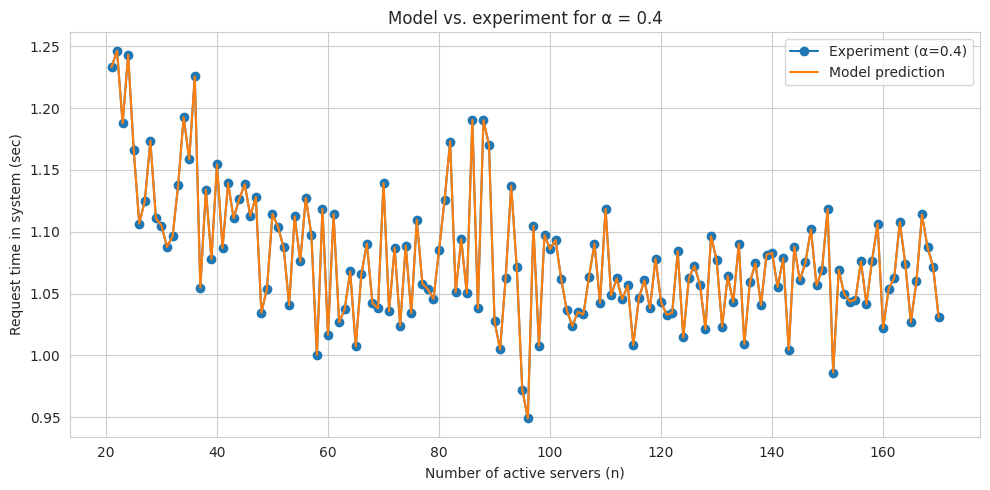

In [65]:
plot_T_for_alpha(0.4, investigate_df, max_index=150, smooth=False)